<a href="https://colab.research.google.com/github/Abhishekksoni/deep_learning/blob/main/02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import make_circles

n_sample = 1000

X, y = make_circles(n_samples=n_sample, noise= 0.03, random_state=42)

In [ ]:
print(f"First 5 X features: {X[:5]}")
print(f"First 5 y features: {y[:5]}")

First 5 X features: [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 y features: [1 1 1 1 0]


In [ ]:
import pandas as pd
circles = pd.DataFrame({"X1": X[:,0],
                        "X2": X[:,1],
                        "label" : y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [ ]:
circles.label.value_counts()

,count
label,
1,500
0,500


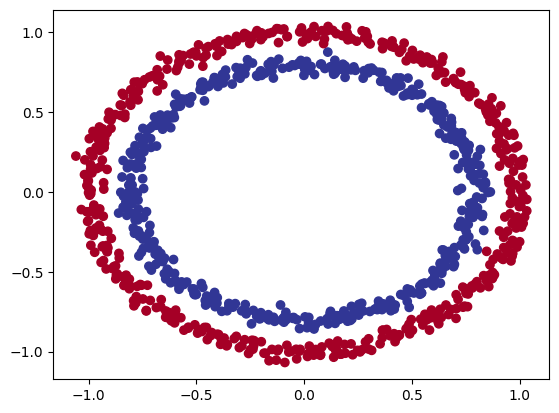

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(x = X[:, 0],
            y = X[:, 1],
            c=y,
            cmap = plt.cm.RdYlBu)

In [ ]:
X.shape, y.shape

((1000, 2), (1000,))

In [ ]:
import torch

In [ ]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [ ]:
X[:5]

tensor([[ 0.7542,  0.2315],
        [-0.7562,  0.1533],
        [-0.8154,  0.1733],
        [-0.3937,  0.6929],
        [ 0.4422, -0.8967]])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size =0.2,
                                                    random_state=42)
len(X_train), len(y_train)

(800, 800)

In [ ]:
X_train.shape, y_train.shape

(torch.Size([800, 2]), torch.Size([800]))

In [ ]:
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
from torch import nn
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=5)
    self.layer_2 = nn.Linear(in_features=5, out_features=1)

  def forward(self, x):
    return self.layer_2(self.layer_1(x))

model_0 = CircleModelV0().to(device)
model_0.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[-0.3175, -0.0588],
                      [ 0.3457, -0.1169],
                      [ 0.6366,  0.1402],
                      [ 0.2077, -0.6787],
                      [-0.1155, -0.4861]])),
             ('layer_1.bias',
              tensor([-0.6866, -0.1224,  0.2153,  0.1275, -0.2869])),
             ('layer_2.weight',
              tensor([[ 0.0579, -0.1596, -0.1655, -0.3235,  0.0234]])),
             ('layer_2.bias', tensor([-0.1818]))])

In [ ]:
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1
))
model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
with torch.inference_mode():
  untrained_pred = model_0(X_test.to(device))
torch.round(untrained_pred[:10])

tensor([[0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.]])

In [ ]:
loss_fun = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(), lr=0.1)


In [ ]:
def accuracy_fun(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct / len(y_pred)) * 100
  return acc

In [ ]:
y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[0.4682],
        [0.5675],
        [0.4812],
        [0.4633],
        [0.9153]], grad_fn=<SliceBackward0>)

In [ ]:
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.6149],
        [0.6382],
        [0.6180],
        [0.6138],
        [0.7141]], grad_fn=<SigmoidBackward0>)

In [ ]:
y_pred = torch.round(y_pred_probs)

y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device)[:5])))

print(torch.eq(y_pred_labels.squeeze(), y_pred.squeeze()))
y_pred

tensor([True, True, True, True, True])


tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]], grad_fn=<RoundBackward0>)

In [ ]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [ ]:
torch.manual_seed(42)
epochs = 100

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  model_0.train()

  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fun(y_logits, y_train)
  acc = accuracy_fun(y_true=y_train, y_pred=y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_0.eval()
  with torch.inference_mode():
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fun(test_logits, y_test)
    test_acc = accuracy_fun(y_true=y_test, y_pred = test_pred)

    if epoch % 10 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69301 | Acc: 51.00% | Test Loss: 0.69502 | Test Acc: 46.00%
Epoch: 10 | Loss: 0.69301 | Acc: 50.75% | Test Loss: 0.69502 | Test Acc: 46.00%
Epoch: 20 | Loss: 0.69301 | Acc: 51.00% | Test Loss: 0.69502 | Test Acc: 46.50%
Epoch: 30 | Loss: 0.69300 | Acc: 50.88% | Test Loss: 0.69502 | Test Acc: 46.50%
Epoch: 40 | Loss: 0.69300 | Acc: 50.62% | Test Loss: 0.69501 | Test Acc: 46.50%
Epoch: 50 | Loss: 0.69300 | Acc: 50.75% | Test Loss: 0.69501 | Test Acc: 46.50%
Epoch: 60 | Loss: 0.69300 | Acc: 51.00% | Test Loss: 0.69500 | Test Acc: 46.50%
Epoch: 70 | Loss: 0.69299 | Acc: 50.75% | Test Loss: 0.69499 | Test Acc: 46.00%
Epoch: 80 | Loss: 0.69299 | Acc: 51.00% | Test Loss: 0.69498 | Test Acc: 46.00%
Epoch: 90 | Loss: 0.69299 | Acc: 50.75% | Test Loss: 0.69497 | Test Acc: 46.00%


In [ ]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


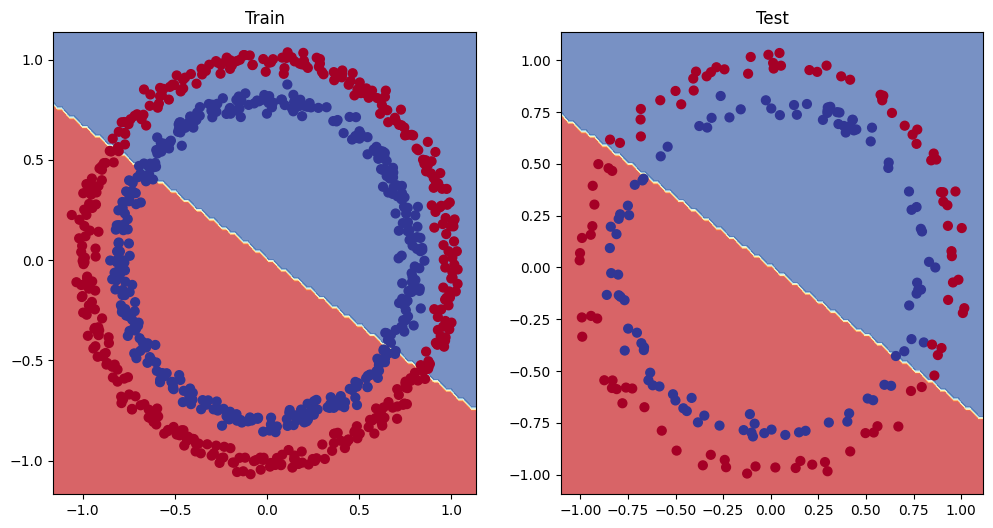

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

In [ ]:
import torch
from torch import nn

In [ ]:
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples, noise=0.03, random_state=42)

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)
X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

In [ ]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=8)
    self.layer_2 = nn.Linear(in_features=8, out_features=8)
    self.layer_3 = nn.Linear(in_features=8, out_features=1)
    self.relu = nn.ReLU()

  def forward(self, x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_1 = CircleModelV1()
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=8, bias=True)
  (layer_2): Linear(in_features=8, out_features=8, bias=True)
  (layer_3): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
)

In [ ]:
y_logits = model_1(X_train)
train_pred = torch.round(torch.sigmoid(y_logits))

In [ ]:
def accuracy_fun(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct / len(y_pred)) * 100
  return acc

In [ ]:
loss_fun = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(), lr=0.1)

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

X_train, X_test, y_train, y_test = X_train.to(device), X_test.to(device), y_train.to(device), y_test.to(device)

for epoch in range(epochs):

  model_1.train()

  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fun(y_logits, y_train)
  acc = accuracy_fun(y_true= y_train, y_pred=y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_1.eval()
  with torch.inference_mode():
    test_logits = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fun(test_logits, y_test)
    test_acc = accuracy_fun(y_true=y_test, y_pred = test_pred)

    if epoch % 100 == 0:

      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.00016 | Acc: 100.00% | Test Loss: 0.09498 | Test Acc: 96.50%
Epoch: 100 | Loss: 0.00028 | Acc: 100.00% | Test Loss: 0.00384 | Test Acc: 100.00%
Epoch: 200 | Loss: 0.00023 | Acc: 100.00% | Test Loss: 0.00309 | Test Acc: 100.00%
Epoch: 300 | Loss: 0.00021 | Acc: 100.00% | Test Loss: 0.00296 | Test Acc: 100.00%
Epoch: 400 | Loss: 0.00019 | Acc: 100.00% | Test Loss: 0.00288 | Test Acc: 100.00%
Epoch: 500 | Loss: 0.00018 | Acc: 100.00% | Test Loss: 0.00281 | Test Acc: 100.00%
Epoch: 600 | Loss: 0.00017 | Acc: 100.00% | Test Loss: 0.00277 | Test Acc: 100.00%
Epoch: 700 | Loss: 0.00015 | Acc: 100.00% | Test Loss: 0.00272 | Test Acc: 100.00%
Epoch: 800 | Loss: 0.00015 | Acc: 100.00% | Test Loss: 0.00270 | Test Acc: 100.00%
Epoch: 900 | Loss: 0.00014 | Acc: 100.00% | Test Loss: 0.00267 | Test Acc: 100.00%


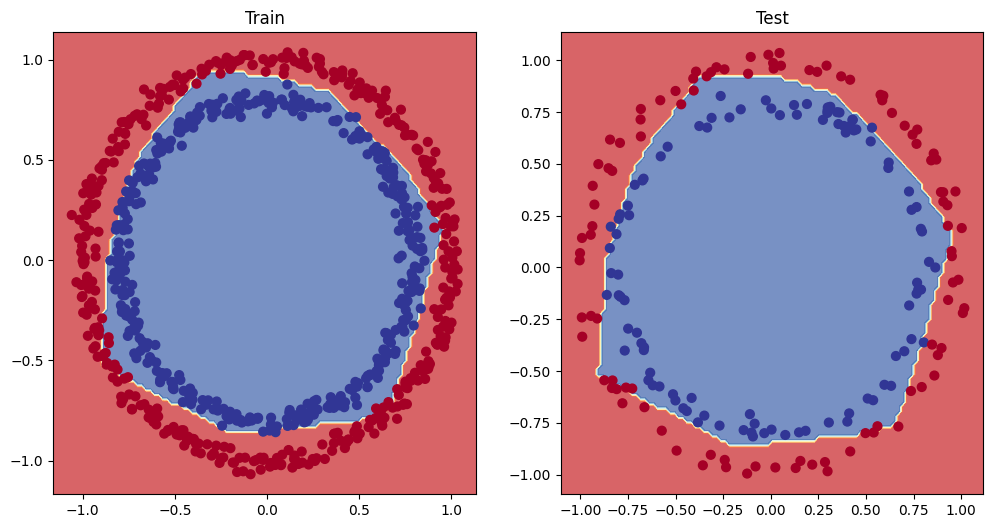

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

Replicating non-linear activation function

In [ ]:
x = torch.arange(-10, 10, 1)
x

tensor([-10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,   3,
          4,   5,   6,   7,   8,   9])

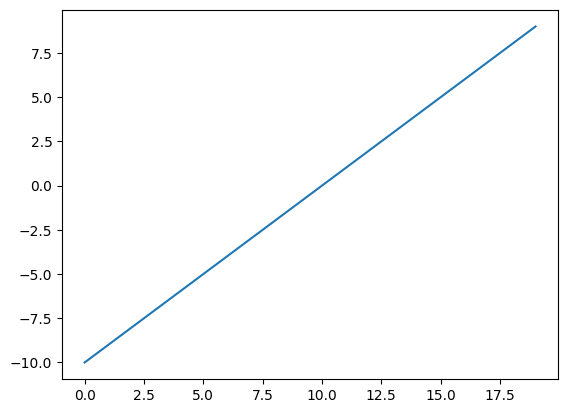

In [ ]:
plt.plot(x)

In [ ]:
def relu(x):
  return torch.maximum(torch.tensor(0), x)

relu(x)

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

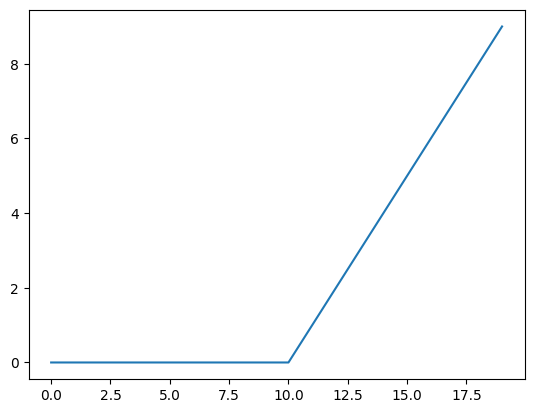

In [ ]:
plt.plot(relu(x))

In [ ]:
def sigmoid(x):
  return 1 / (1 + torch.exp(-x))

sigmoid(x)

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

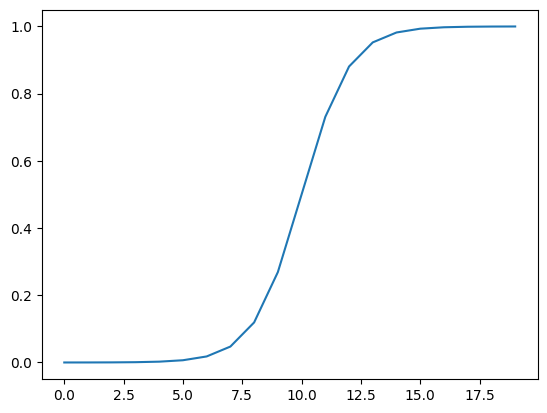

In [ ]:
plt.plot(sigmoid(x))

Multi-class data

tensor([[-8.4134,  6.9352],
        [-5.7665, -6.4312],
        [-6.0421, -6.7661],
        [ 3.9508,  0.6984],
        [ 4.2505, -0.2815]]) tensor([3., 2., 2., 1., 1.])


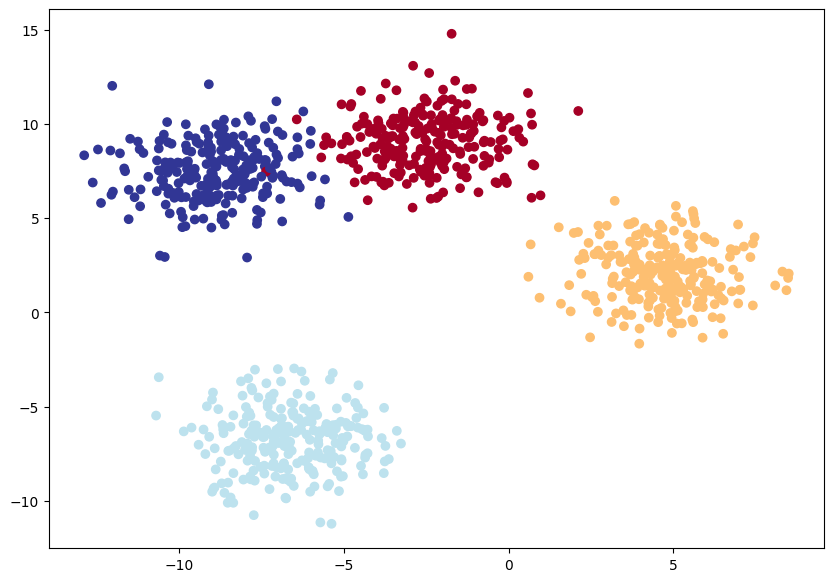

In [ ]:
import torch
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

n_samples = 1000
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

X_blob, y_blob = make_blobs(n_samples,
                            centers = NUM_CLASSES,
                            cluster_std = 1.5,
                            random_state = RANDOM_SEED)

X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.float)
print(X_blob[:5], y_blob[:5])

X_train, X_test, y_train, y_test = train_test_split(X_blob,
                                                    y_blob,
                                                    test_size =0.2,
                                                    random_state = 42)
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:,0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)

In [ ]:
class MultiClassModelV0(nn.Module):
  def __init__(self, input_features, output_features, hidden_units):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=output_features)
    )
  def forward(self,x):
    return self.layer_stack(x)


model_2 = MultiClassModelV0(input_features=NUM_FEATURES,
                            output_features=NUM_CLASSES,
                            hidden_units=8).to(device)
model_2

MultiClassModelV0(
  (layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [ ]:
y_logits = model_2(X_train.to(device))
y_pred = torch.softmax(y_logits, dim=1)

print(y_logits[:5])
print(y_pred[:5])

tensor([[-1.2711, -0.6494, -1.4740, -0.7044],
        [ 0.2210, -1.5439,  0.0420,  1.1531],
        [ 2.8698,  0.9143,  3.3169,  1.4027],
        [ 1.9576,  0.3125,  2.2244,  1.1324],
        [ 0.5458, -1.2381,  0.4441,  1.1804]], grad_fn=<SliceBackward0>)
tensor([[0.1838, 0.3422, 0.1500, 0.3239],
        [0.2199, 0.0377, 0.1839, 0.5586],
        [0.3406, 0.0482, 0.5326, 0.0785],
        [0.3405, 0.0657, 0.4446, 0.1492],
        [0.2527, 0.0424, 0.2283, 0.4766]], grad_fn=<SliceBackward0>)


In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_2.parameters(), lr=0.1)

In [ ]:
def accuracy_fun(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct / len(y_pred)) * 100
  return acc

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

X_train, X_test, y_train, y_test = X_train.to(device), X_test.to(device), y_train.to(device), y_test.to(device)

for epoch in range(epochs):
  model_2.train()

  y_logits = model_2(X_train).squeeze()
  y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

  loss =loss_fn(y_logits, y_train.long())
  acc = accuracy_fun(y_true=y_train, y_pred=y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_2.eval()

  with torch.inference_mode():
    test_logits = model_2(X_test).squeeze()
    test_loss = loss_fn(test_logits, y_test.long())

    test_pred =torch.softmax(test_logits, dim=1).argmax(dim=1)
    test_acc = accuracy_fun(y_true=y_test, y_pred=test_pred)

    if epoch % 100 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.01695 | Acc: 99.50% | Test Loss: 0.00394 | Test Acc: 100.00%
Epoch: 100 | Loss: 0.01697 | Acc: 99.38% | Test Loss: 0.00396 | Test Acc: 100.00%
Epoch: 200 | Loss: 0.01696 | Acc: 99.50% | Test Loss: 0.00394 | Test Acc: 100.00%
Epoch: 300 | Loss: 0.01696 | Acc: 99.38% | Test Loss: 0.00412 | Test Acc: 100.00%
Epoch: 400 | Loss: 0.01696 | Acc: 99.50% | Test Loss: 0.00395 | Test Acc: 100.00%
Epoch: 500 | Loss: 0.01695 | Acc: 99.50% | Test Loss: 0.00394 | Test Acc: 100.00%
Epoch: 600 | Loss: 0.01701 | Acc: 99.38% | Test Loss: 0.00401 | Test Acc: 100.00%
Epoch: 700 | Loss: 0.01695 | Acc: 99.50% | Test Loss: 0.00394 | Test Acc: 100.00%
Epoch: 800 | Loss: 0.01698 | Acc: 99.50% | Test Loss: 0.00383 | Test Acc: 100.00%
Epoch: 900 | Loss: 0.01695 | Acc: 99.50% | Test Loss: 0.00393 | Test Acc: 100.00%


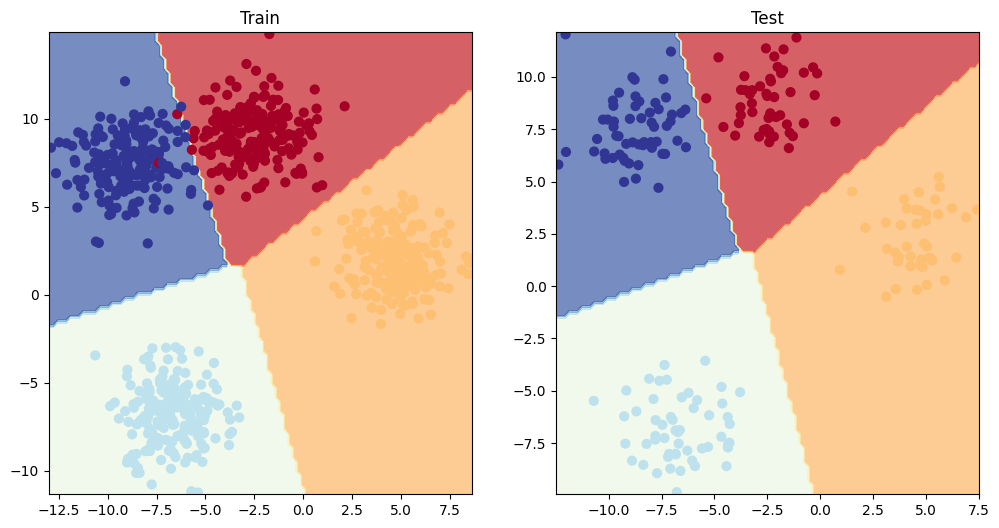

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_2, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_2, X_test, y_test)

In [ ]:
try:
    from torchmetrics import Accuracy
except:
    !pip install torchmetrics==0.9.3 # this is the version we're using in this notebook (later versions exist here: https://torchmetrics.readthedocs.io/en/stable/generated/CHANGELOG.html#changelog)
    from torchmetrics import Accuracy

# Setup metric and make sure it's on the target device
torchmetrics_accuracy = Accuracy(task='multiclass', num_classes=4).to(device)

# Calculate accuracy
y_test = y_test.long()
torchmetrics_accuracy(y_pred, y_test)

ValueError: The `preds` and `target` should have the same first dimension.